In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.model_selection import train_test_split

from sklearn.tree import plot_tree


from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_LIMPOS
from src.graficos import plot_coeficientes, plot_comparar_metricas_modelos
from src.models import RANDOM_STATE
from src.models import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

sns.set_theme(palette="bright")

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [3]:
X = df.drop(columns=["Species"])
y = df["Species"]

le = LabelEncoder()

y = le.fit_transform(y)

In [4]:
y[:5]

array([0, 0, 0, 0, 0])

In [5]:
le.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [6]:
le.inverse_transform([0, 1, 2])

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [7]:
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [8]:
preprocessamento = Pipeline(
    steps=[
        ("scaler", StandardScaler())]
)

In [16]:
classificadores = {
    "DummyClassifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified")
    },
    "LogisticRegression": {
        "preprocessor": preprocessamento,
        "classificador": LogisticRegression()
    },
    "DecisionTree": {
        "preprocessor": None,
        "classificador": DecisionTreeClassifier()
    },
        "RandomForest": {
        "preprocessor": None,
        "classificador": RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE)
    },
    "XGBoost": {
        "preprocessor": None,
        "classificador": XGBClassifier(n_jobs=-1, random_state=RANDOM_STATE)
    },
    "LightGBM": {
            "preprocessor": None,
            "classificador": LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
        }
}

In [17]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador, multi_class=True)
    for nome_modelo, classificador in classificadores.items()
}


df_resultados = organiza_resultados(resultados)


df_resultados

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1_weighted,test_precision_weighted,test_recall_weighted,test_roc_auc_ovr,test_average_precision,time_seconds
0,DummyClassifier,0.001999,0.027977,0.4,0.400735,0.396871,0.396984,0.4,0.610981,0.404594,0.029976
1,DummyClassifier,0.001999,0.058952,0.28,0.281863,0.276526,0.279238,0.28,0.548815,0.359812,0.060951
2,DummyClassifier,0.002998,0.037971,0.26,0.262255,0.257176,0.256886,0.26,0.489379,0.331514,0.040969
3,LogisticRegression,0.013833,0.04097,1.0,1.0,1.0,1.0,1.0,1.0,0.7713,0.054802
4,LogisticRegression,0.010991,0.02798,0.92,0.919118,0.92,0.92,0.92,0.995172,0.762167,0.03897
5,LogisticRegression,0.010009,0.028967,0.94,0.941176,0.939948,0.940972,0.94,0.997623,0.842977,0.038976
6,DecisionTree,0.004016,0.025977,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.029993
7,DecisionTree,0.003997,0.024985,0.92,0.919118,0.92,0.92,0.92,0.939654,0.874724,0.028982
8,DecisionTree,0.004977,0.022997,0.94,0.941176,0.939948,0.940972,0.94,0.955437,0.907936,0.027974
9,RandomForest,0.273116,0.267223,0.98,0.979167,0.979963,0.981111,0.98,1.0,1.0,0.540339


In [18]:
df_resultados.groupby("model").mean().sort_values("test_accuracy", ascending=False)

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1_weighted,test_precision_weighted,test_recall_weighted,test_roc_auc_ovr,test_average_precision,time_seconds
model,,,,,,,,,,
DecisionTree,0.00433,0.024653,0.953333,0.953431,0.953316,0.953657,0.953333,0.96503,0.927553,0.028983
LogisticRegression,0.011611,0.032639,0.953333,0.953431,0.953316,0.953657,0.953333,0.997599,0.792148,0.04425
RandomForest,0.274783,0.146272,0.953333,0.953023,0.953267,0.954324,0.953333,0.993229,0.988013,0.421055
LightGBM,0.053626,0.049296,0.946667,0.946078,0.946489,0.948514,0.946667,0.986018,0.972696,0.102921
XGBoost,0.090925,0.051959,0.946667,0.946078,0.946129,0.94752,0.946667,0.989382,0.981006,0.142884
DummyClassifier,0.002332,0.041633,0.313333,0.314951,0.310191,0.311036,0.313333,0.549725,0.365307,0.043965


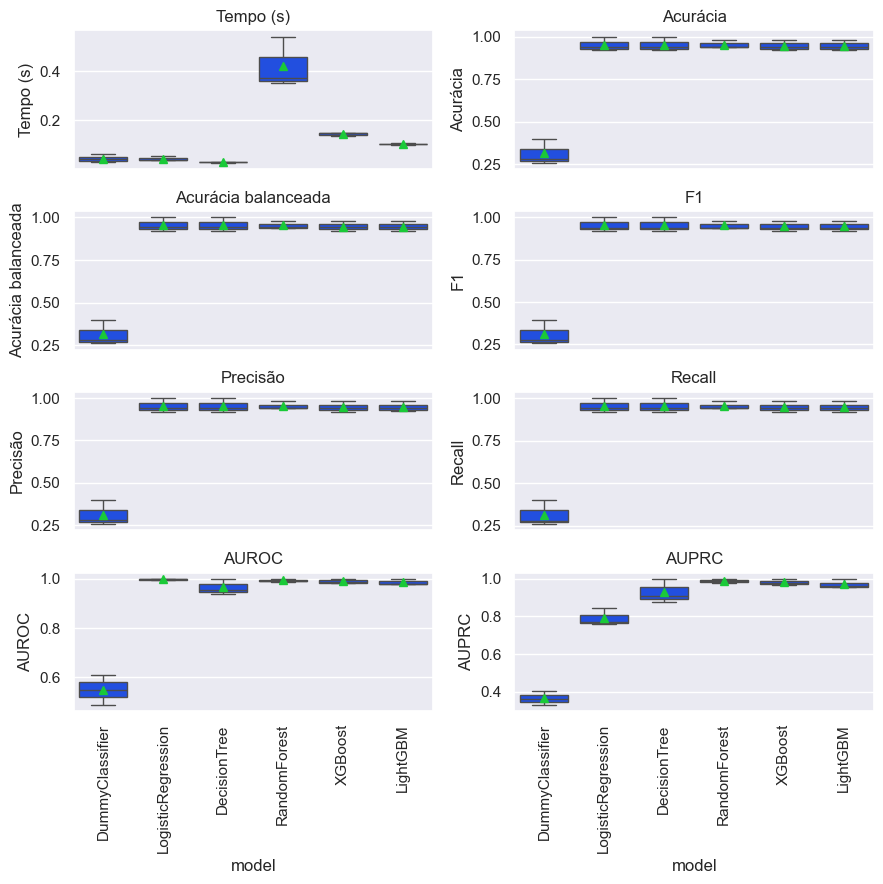

In [19]:
plot_comparar_metricas_modelos(df_resultados, multi_class=True)

Hiperparâmetros usualmente utilizados para otimizar DecisionTreeClassifier:

- **`max_depth`**: Limita a profundidade da árvore, prevenindo overfitting.
- **`min_samples_split`**: Número mínimo de amostras para dividir um nó.
- **`min_samples_leaf`**: Mínimo de amostras em um nó folha.
- **`max_features`**: Número de features a serem consideradas na divisão.
- **`criterion`**: Função para medir a qualidade da divisão.
- **`splitter`**: Estratégia de divisão dos nós.
- **`class_weight`**: Ponderação das classes para lidar com desbalanceamento.
- **`ccp_alpha`**: Controla a poda de custo-complexidade. Maior valor resulta em mais poda.


In [ ]:
# param grid para DecisionTreeClassifier
param_grid = {
    "clf__max_depth": [3, 5, 10, None],  # Limita a profundidade da árvore
    "clf__min_samples_split": [2, 5, 10],  # Mínimo de amostras para dividir um nó
    "clf__min_samples_leaf": [1, 2, 5],  # Mínimo de amostras em um nó folha
    #"clf__max_features": [None, "sqrt", "log2"],  # Features para divisão
    "clf__criterion": ["gini", "entropy"],  # Critério para divisão
    "clf__splitter": ["best", "random"],  # Estratégia de divisão dos nós
    #"clf__class_weight": [None, "balanced"],  # Ponderação das classes
    #"clf__ccp_alpha": [0.0, 0.01, 0.1]  # Controla a poda
}


In [23]:
clf = DecisionTreeClassifier(random_state=RANDOM_STATE)

grid_search = grid_search_cv_classificador(
    clf, param_grid, kf, preprocessamento, refit_metric="accuracy", multi_class=True
)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__criterion': ['gini', 'entropy'], 'clf__max_depth': [3, 5, ...], 'clf__min_samples_leaf': [1, 2, ...], 'clf__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls 

In [24]:
grid_search.fit(X, y)

Fitting 3 folds for each of 144 candidates, totalling 432 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__criterion': ['gini', 'entropy'], 'clf__max_depth': [3, 5, ...], 'clf__min_samples_leaf': [1, 2, ...], 'clf__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls 

In [25]:
grid_search.best_params_

{'clf__criterion': 'entropy',
 'clf__max_depth': 10,
 'clf__min_samples_leaf': 2,
 'clf__min_samples_split': 2,
 'clf__splitter': 'random'}

In [26]:
grid_search.best_score_

np.float64(0.96)

In [27]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exceptio

In [28]:
grid_search.best_estimator_["preprocessor"].get_feature_names_out()

array(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
      dtype=object)

In [30]:
grid_search.best_estimator_["clf"].classes_

array([0, 1, 2])

In [31]:
y_pred = grid_search.best_estimator_.predict(X)

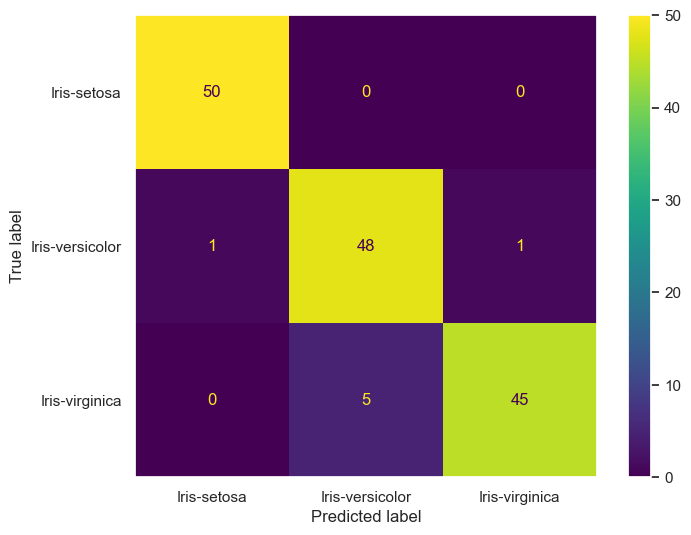

In [54]:
#Matriz de confusão
fig,ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X, y, display_labels=le.classes_, ax=ax)
plt.grid(False)
plt.show()


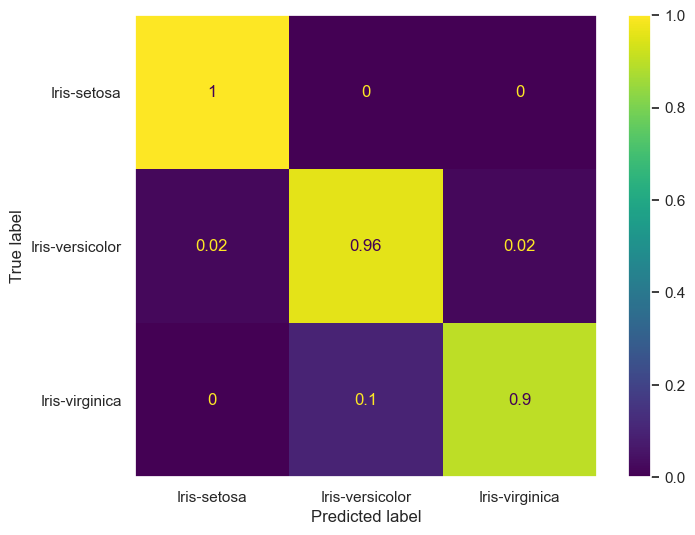

In [55]:
#Matriz de confusão
fig,ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X, y, display_labels=le.classes_, ax=ax, normalize="true")
plt.grid(False)
plt.show()

In [56]:
#Report de classificação
print(classification_report(y, y_pred, target_names=le.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       0.98      1.00      0.99        50
Iris-versicolor       0.91      0.96      0.93        50
 Iris-virginica       0.98      0.90      0.94        50

       accuracy                           0.95       150
      macro avg       0.95      0.95      0.95       150
   weighted avg       0.95      0.95      0.95       150



In [71]:
grid_search.best_estimator_["clf"].feature_importances_

array([0.00795576, 0.03028146, 0.03396752, 0.92779525])

In [ ]:
pd.Series(
    grid_search.best_estimator_["clf"].feature_importances_, 
    index=X.columns
    ).sort_values(ascending=False)

PetalWidthCm     0.927795
PetalLengthCm    0.033968
SepalWidthCm     0.030281
SepalLengthCm    0.007956
dtype: float64

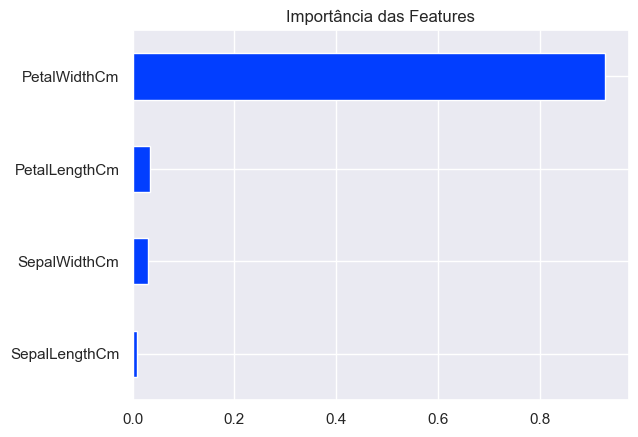

In [78]:
pd.Series(
    grid_search.best_estimator_["clf"].feature_importances_, 
    index=X.columns
    ).sort_values(ascending=True).plot(kind="barh", title="Importância das Features");

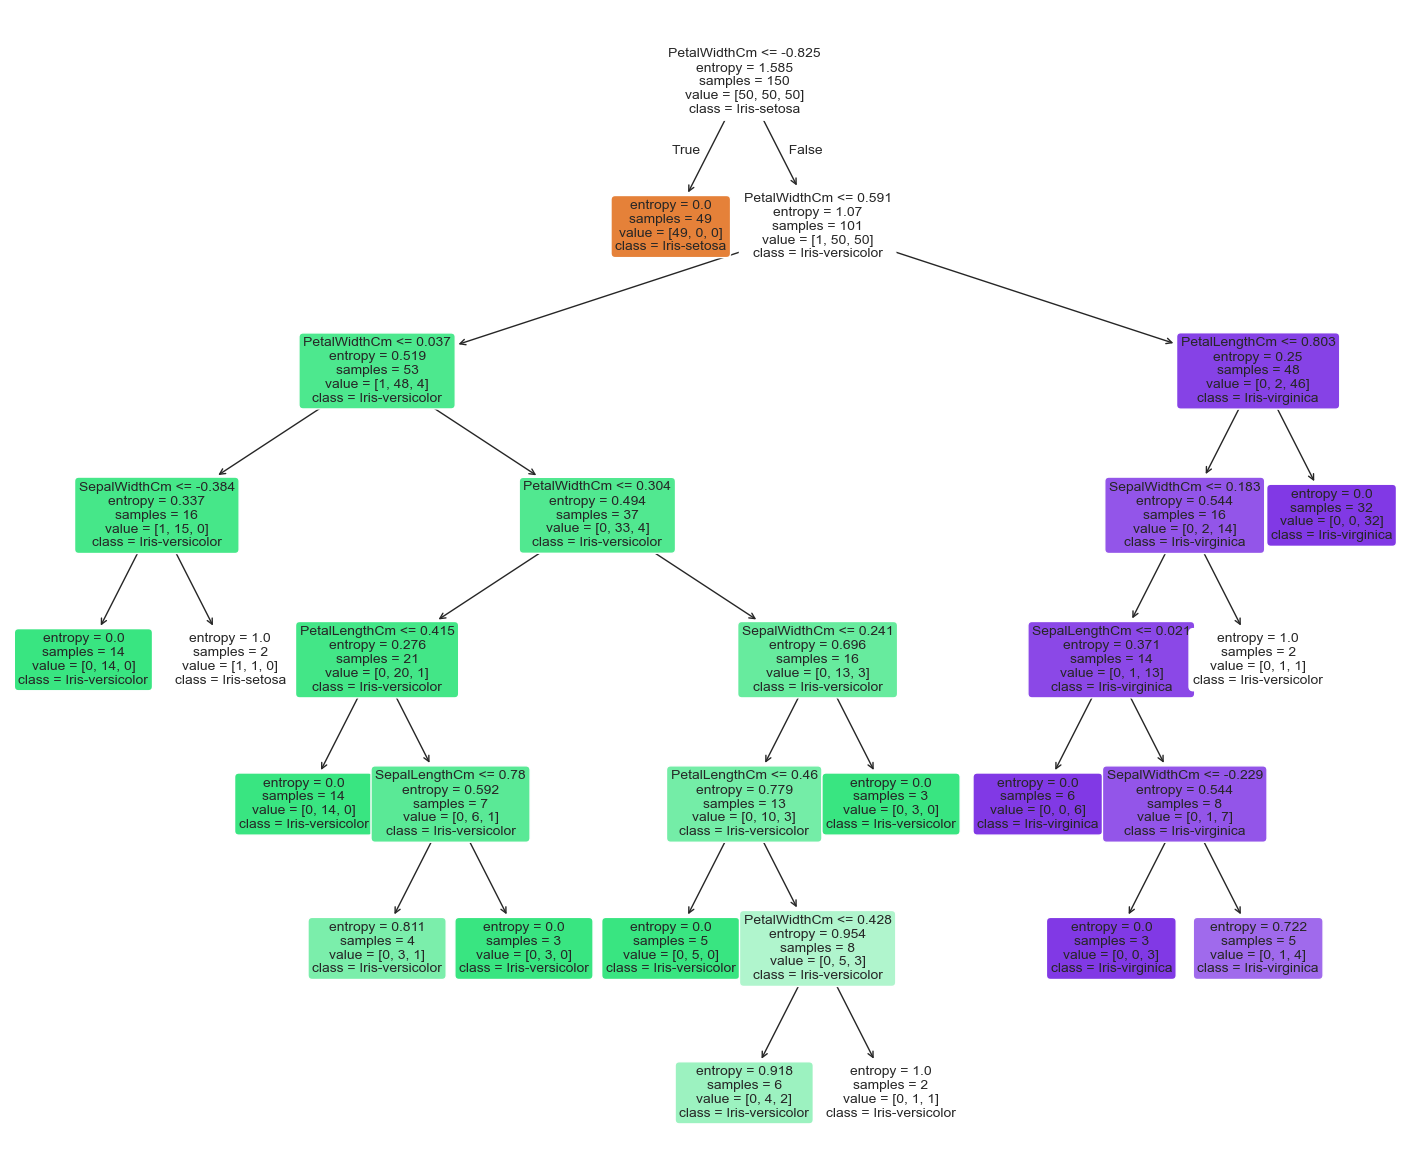

In [65]:
#Vizualizando a Árvore de decisão
plt.figure(figsize=(18, 15))
plot_tree(
    grid_search.best_estimator_["clf"], 
    feature_names=X.columns, 
    class_names=le.classes_, 
    filled=True, 
    rounded=True,
    fontsize=10);

plt.show()